In [19]:
import numpy as np
import matplotlib.pyplot as plt
import random, time

# --- Step 1: Generate 20 random points with min distance > 10 ---
num_points = 20
min_dist = 15

def generate_points(n, min_dist):
    points = []
    while len(points) < n:
        candidate = np.random.rand(2) * 100  # random in [0,100]x[0,100]
        if all(np.linalg.norm(candidate - p) > min_dist for p in points):
            points.append(candidate)
    return np.array(points)

points = generate_points(num_points, min_dist)

def distance(a, b):
    return np.linalg.norm(points[a] - points[b])

def total_cost(route):
    return sum(distance(route[i], route[(i + 1) % num_points]) for i in range(num_points))

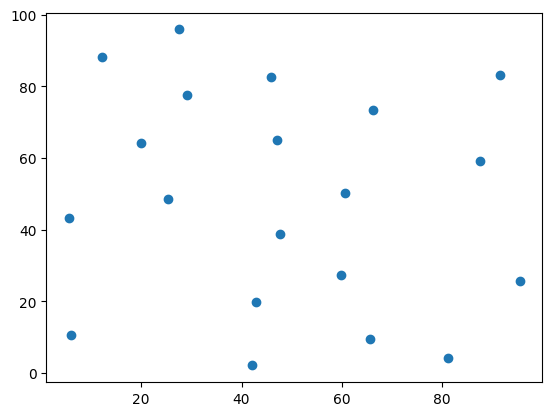

In [20]:
# print(points)
plt.scatter(points[:,0],points[:,1])

In [21]:
# --- Step 2: Initialize 50 random parents ---
def random_route():
    route = list(range(num_points))
    random.shuffle(route)
    return route

population_size = 50
population = [random_route() for _ in range(population_size)]

In [22]:
# --- Step 3: Define crossover and mutation ---
def crossover(parent1, parent2):
    a, b = sorted(random.sample(range(num_points), 2))
    child = [-1] * num_points
    child[a:b] = parent1[a:b]
    fill = [gene for gene in parent2 if gene not in child]
    idx = 0
    for i in range(num_points):
        if child[i] == -1:
            child[i] = fill[idx]
            idx += 1
    return child

def mutate(route):
    i, j = random.sample(range(num_points), 2)
    route[i], route[j] = route[j], route[i]
    return route

In [25]:
# --- Step 4: GA Loop ---
num_generations = 50
best_costs = []
start_time = time.time()  # start timer
for gen in range(num_generations):
    # Evaluate fitness
    population.sort(key=total_cost)
    costs = [total_cost(r) for r in population]
    best_costs.append(min(costs))

    # Print progress
    print(f"Generation {gen+1}: Best cost = {best_costs[-1]:.2f}")

    # --- Step 5: Generate new population ---
    new_pop = population[:10]  # keep top 10 elites

    # Crossover: 32 children
    for _ in range(32):
        p1, p2 = random.sample(population[:25], 2)
        new_pop.append(crossover(p1, p2))

    # Mutation: 14 children
    for _ in range(14):
        p = random.choice(population[:20])
        new_pop.append(mutate(p.copy()))

    # New random routes: 4
    for _ in range(4):
        new_pop.append(random_route())

    population = new_pop

end_time = time.time()
elapsed = end_time - start_time

best_route = min(population, key=total_cost)
best_cost = total_cost(best_route)
print("\nBest TSP cost found:", round(best_cost, 2))
print("Best route order:", best_route)
print(f"Time to implement: {elapsed:.4f} seconds")

Generation 1: Best cost = 500.76
Generation 2: Best cost = 500.76
Generation 3: Best cost = 492.18
Generation 4: Best cost = 492.18
Generation 5: Best cost = 492.18
Generation 6: Best cost = 476.84
Generation 7: Best cost = 476.84
Generation 8: Best cost = 476.84
Generation 9: Best cost = 476.84
Generation 10: Best cost = 476.84
Generation 11: Best cost = 470.96
Generation 12: Best cost = 470.96
Generation 13: Best cost = 470.96
Generation 14: Best cost = 470.96
Generation 15: Best cost = 470.96
Generation 16: Best cost = 470.96
Generation 17: Best cost = 470.96
Generation 18: Best cost = 470.96
Generation 19: Best cost = 470.96
Generation 20: Best cost = 470.96
Generation 21: Best cost = 470.96
Generation 22: Best cost = 470.96
Generation 23: Best cost = 470.96
Generation 24: Best cost = 470.96
Generation 25: Best cost = 470.96
Generation 26: Best cost = 470.96
Generation 27: Best cost = 470.96
Generation 28: Best cost = 470.96
Generation 29: Best cost = 470.96
Generation 30: Best cos

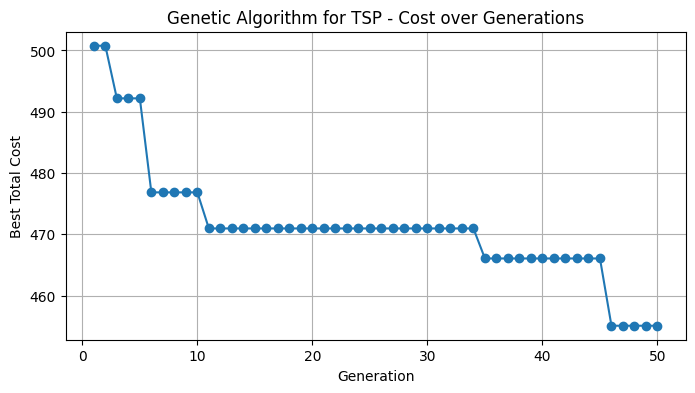

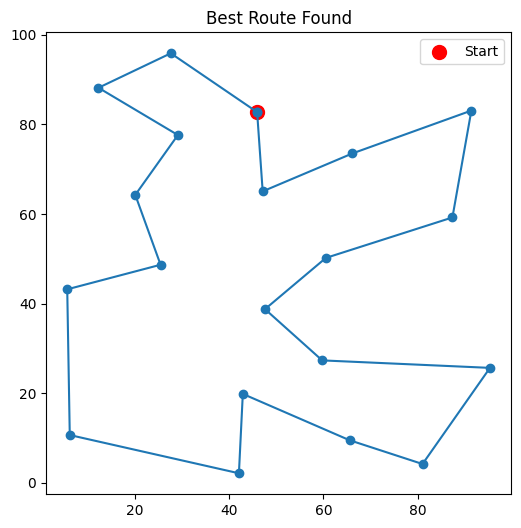

In [26]:
# --- Step 7: Plot results ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_generations + 1), best_costs, marker='o')
plt.title("Genetic Algorithm for TSP - Cost over Generations")
plt.xlabel("Generation")
plt.ylabel("Best Total Cost")
plt.grid(True)
plt.show()

# --- Step 8: Plot best route ---
route_points = np.array([points[i] for i in best_route + [best_route[0]]])
plt.figure(figsize=(6, 6))
plt.plot(route_points[:, 0], route_points[:, 1], '-o')
plt.scatter(route_points[0, 0], route_points[0, 1], c='red', s=100, label="Start")
plt.title("Best Route Found")
plt.legend()
plt.show()

In [17]:
from itertools import permutations
# Brute force true optimal route ---
# Caution: Do NOT runt this cell for more than 10 Points
start_brute = time.time()
best_brute_cost = float('inf')
best_brute_route = None

for perm in permutations(range(num_points)):
    c = total_cost(perm)
    if c < best_brute_cost:
        best_brute_cost = c
        best_brute_route = perm

end_brute = time.time()
brute_time = end_brute - start_brute

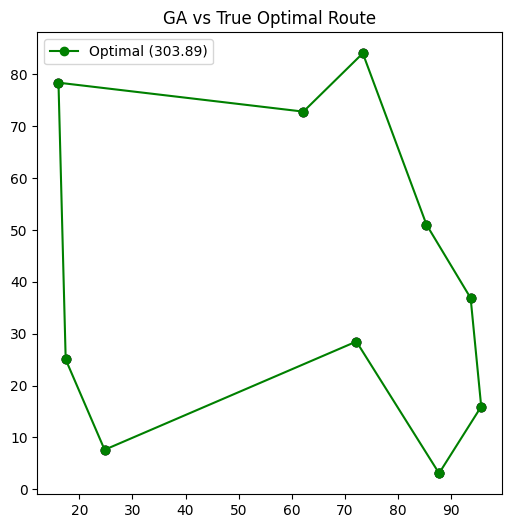

In [18]:
# Plot Brute-force route
def plot_route(route, title, color):
    route_points = np.array([points[i] for i in route + (route[0],)])
    plt.plot(route_points[:, 0], route_points[:, 1], '-o', color=color, label=title)

plt.figure(figsize=(6, 6))
plot_route(best_brute_route, f"Optimal ({best_brute_cost:.2f})", 'green')
plt.scatter(points[:, 0], points[:, 1], c='black', s=40)
plt.legend()
plt.title("GA vs True Optimal Route")
plt.show()